This notebook demonstrates how to compute the price of a **European call option** using the **Black-Scholes model**, and analyze the **Profit & Loss (PNL)** depending on the underlying asset price at maturity.

We will:
(1) Define the Black-Scholes formula for a European call,
(2) Set realistic financial parameters,
(3) Compute the option price,
(4) Analyze the PNL under different scenarios,
(5) Plot the evolution of the PNL.

In [2]:
import math
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Black-Scholes formula for a European call option

def black_scholes_call(S, K, T, r, sigma):
    """
    Compute the price of a European call option using the Black-Scholes model.
    
    Parameters:
    S : float : Current price of the underlying asset
    K : float : Strike price of the option
    T : float : Time to maturity (in years)
    r : float : Risk-free interest rate (continuously compounded)
    sigma : float : Annual volatility of the underlying
    
    Returns:
    float : Price of the call option
    """
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

In [4]:
# Option parameters
S0 = 50       # Current stock price
K = 55        # Strike price
T = 0.5       # Time to expiration (in years)
r = 0.05      # Risk-free interest rate
sigma = 0.3   # Annual volatility

# Compute the price of the European call
call_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Price of the European call : {call_price:.2f} €")

Price of the European call : 2.79 €


In [5]:
# Price of the call option from Black-Scholes
C = round(call_price, 2)

# Simulated asset prices at maturity (ST)
ST_list = [50, 55, 57, 60, 70]
PNL_list = [max(ST - K, 0) - C for ST in ST_list]

# Display PNL for each scenario
for ST, pnl in zip(ST_list, PNL_list):
    print(f"ST = {ST} € → PNL = {pnl:.2f} €")

ST = 50 € → PNL = -2.79 €
ST = 55 € → PNL = -2.79 €
ST = 57 € → PNL = -0.79 €
ST = 60 € → PNL = 2.21 €
ST = 70 € → PNL = 12.21 €


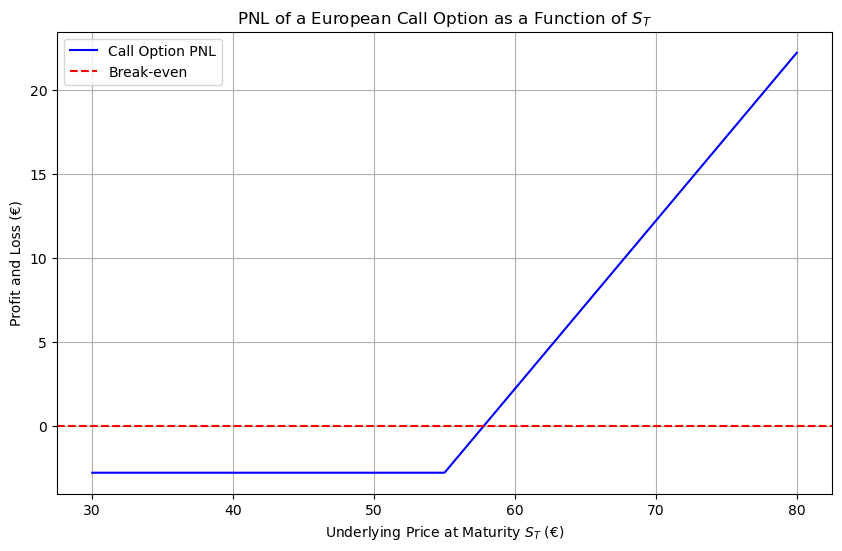

In [6]:
# Generate a range of possible underlying prices at maturity
n_points = 1000
ST_values = np.linspace(30, 80, n_points)

# Compute payoff and PNL
payoff = np.maximum(ST_values - K, 0)
PNL = payoff - C

# Plot the PNL curve
plt.figure(figsize=(10, 6))
plt.plot(ST_values, PNL, label="Call Option PNL", color='blue')
plt.axhline(0, color='red', linestyle='--', label="Break-even")
plt.title("PNL of a European Call Option as a Function of $S_T$")
plt.xlabel("Underlying Price at Maturity $S_T$ (€)")
plt.ylabel("Profit and Loss (€)")
plt.legend()
plt.grid(True)
plt.show()

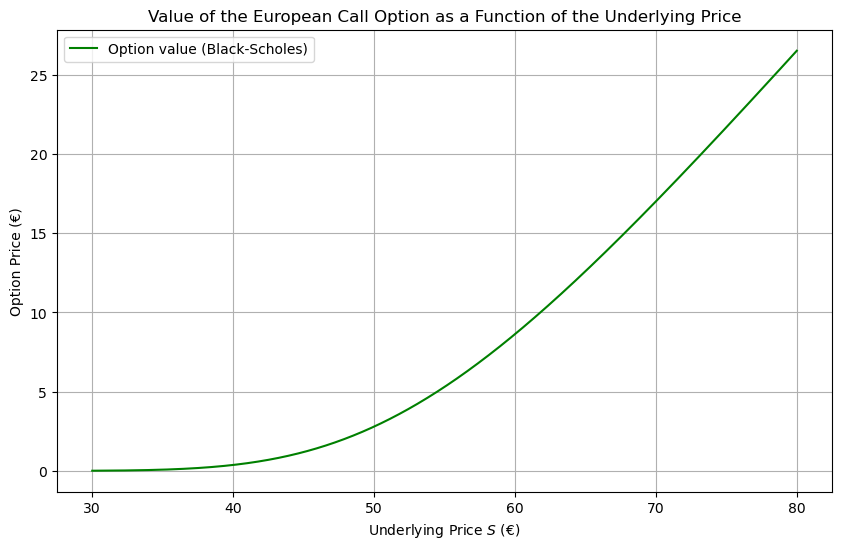

In [7]:
# Generate a range of possible underlying prices at maturity
n_points = 1000
S_values = np.linspace(30, 80, n_points)

# Compute option value for each price
option_values = [black_scholes_call(S, K, T, r, sigma) for S in S_values]  

# Plot the value curve
plt.figure(figsize=(10, 6))
plt.plot(S_values, option_values, label="Option value (Black-Scholes)", color='green')
plt.title("Value of the European Call Option as a Function of the Underlying Price")
plt.xlabel("Underlying Price $S$ (€)")
plt.ylabel("Option Price (€)")
plt.grid(True)
plt.legend()
plt.show()